# 🔒 Privacy Policy Generator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/privacy-policy-gen/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/privacy-policy-gen/demo.ipynb)

**Pain point:** *"Legal templates cost money and are still generic."*

Answer a short questionnaire about your product and get a GDPR/CCPA-aware privacy policy draft plus a compliance checklist that tells you what the policy alone can't fix. Runs fully offline.

**What this notebook covers:**
1. The engine — a company profile drives conditional policy sections
2. Generating a policy for a SaaS serving the EU and California
3. The compliance checklist — the actions a policy document can't do for you
4. How the policy adapts across three very different companies
5. Try your own profile


## Step 1 — The engine

A `CompanyProfile` dataclass captures the questionnaire: what data you collect, why, cookies/analytics, third-party processors, whether you sell data, which regions you serve, retention, and whether children use the product.

Two functions consume it:
- **`generate_policy`** — assembles Markdown sections; GDPR rights only appear if you serve the EU, CCPA rights only for California, the "Do Not Sell" language only if you actually sell data, COPPA language only if children are involved.
- **`compliance_checklist`** — the honest part: flags what still needs *doing* (consent banner, DPAs, homepage opt-out link, lawyer review), because a policy document is necessary but not sufficient.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, List

DATA_CATEGORIES: Dict[str, str] = {
    "contact": "Contact details (name, email address, phone number)",
    "account": "Account credentials (username, hashed password)",
    "payment": "Payment information (billing address, last four card digits — processed by our payment provider)",
    "usage": "Usage data (pages visited, features used, session duration)",
    "device": "Device data (browser type, operating system, IP address)",
    "location": "Approximate location derived from IP address",
    "content": "Content you create or upload within the service",
}

GDPR_RIGHTS = [
    "Access — request a copy of the personal data we hold about you",
    "Rectification — correct inaccurate or incomplete data",
    "Erasure — ask us to delete your data ('right to be forgotten')",
    "Restriction — limit how we process your data",
    "Portability — receive your data in a machine-readable format",
    "Objection — object to processing based on legitimate interests",
    "Withdraw consent — at any time, without affecting prior processing",
]

CCPA_RIGHTS = [
    "Know — what personal information we collect, use, and disclose",
    "Delete — request deletion of your personal information",
    "Correct — request correction of inaccurate personal information",
    "Opt out — of the sale or sharing of your personal information",
    "Non-discrimination — equal service and price, even if you exercise your rights",
]


@dataclass
class CompanyProfile:
    company: str
    website: str
    contact_email: str
    data_categories: List[str] = field(default_factory=list)
    purposes: List[str] = field(default_factory=lambda: ["provide and improve the service"])
    uses_cookies: bool = True
    uses_analytics: bool = False
    third_parties: List[str] = field(default_factory=list)
    sells_data: bool = False
    serves_eu: bool = False
    serves_california: bool = False
    collects_children: bool = False
    retention_months: int = 24


def compliance_checklist(p: CompanyProfile) -> List[Dict[str, str]]:
    """Return [{level: ok|action|warning, item: str}] — what the policy covers and what still needs doing."""
    items: List[Dict[str, str]] = []
    if p.serves_eu:
        items.append({"level": "ok", "item": "GDPR rights section included (7 rights + supervisory authority)"})
        items.append({"level": "action", "item": "GDPR: document your lawful basis per purpose in a Records of Processing (Art. 30)"})
        if p.third_parties:
            items.append({"level": "action", "item": "GDPR: ensure Data Processing Agreements exist with each third-party processor"})
    if p.serves_california:
        items.append({"level": "ok", "item": "CCPA/CPRA rights section included (know, delete, correct, opt out)"})
        if p.sells_data:
            items.append({"level": "warning", "item": "CCPA: you sell/share data — a 'Do Not Sell or Share My Personal Information' link is REQUIRED on your homepage"})
        else:
            items.append({"level": "ok", "item": "CCPA: policy states you do not sell personal information"})
    if p.collects_children:
        items.append({"level": "warning", "item": "COPPA: collecting data from children under 13 requires verifiable parental consent — consult counsel before launch"})
    if p.uses_analytics:
        items.append({"level": "action", "item": "Cookie consent: analytics cookies need opt-in consent in the EU (ePrivacy) — add a consent banner"})
    if "payment" in p.data_categories:
        items.append({"level": "ok", "item": "Payment data handled by processor — policy states you never store full card numbers"})
    if not p.contact_email:
        items.append({"level": "warning", "item": "No contact email set — privacy laws require a working contact channel"})
    items.append({"level": "action", "item": "Review the generated policy with a qualified lawyer before publishing"})
    return items


def generate_policy(p: CompanyProfile, effective_date: str) -> str:
    s: List[str] = [f"# Privacy Policy — {p.company}", f"\n*Effective date: {effective_date}*\n"]
    s.append(f"This policy explains how {p.company} (\"we\", \"us\") collects, uses, and protects your personal "
             f"information when you use {p.website}.\n")

    s.append("## 1. Information We Collect\n")
    for cat in p.data_categories:
        s.append(f"- {DATA_CATEGORIES.get(cat, cat)}")
    if not p.data_categories:
        s.append("- We do not collect personal information beyond what you voluntarily provide.")

    s.append("\n## 2. How We Use Your Information\n")
    s.append("We use your information to:\n")
    for purpose in p.purposes:
        s.append(f"- {purpose[0].upper() + purpose[1:]}")
    if p.serves_eu:
        s.append("\nWhere GDPR applies, we rely on the following legal bases: performance of a contract "
                 "(providing the service), legitimate interests (improving and securing the service), and "
                 "consent (marketing and non-essential cookies).")

    s.append("\n## 3. Cookies\n")
    if p.uses_cookies:
        s.append("We use essential cookies to keep you signed in and remember preferences."
                 + (" We also use analytics cookies to understand how the service is used; "
                    "you can decline these via the cookie banner." if p.uses_analytics else ""))
    else:
        s.append("We do not use cookies.")

    s.append("\n## 4. Sharing Your Information\n")
    if p.third_parties:
        s.append("We share data only with service providers who help us operate the service:\n")
        for tp in p.third_parties:
            s.append(f"- {tp}")
        s.append("\nEach provider is bound by a data processing agreement and may not use your data for its own purposes.")
    else:
        s.append("We do not share your personal information with third parties.")
    s.append("\nWe **" + ("do" if p.sells_data else "do not") + "** sell your personal information."
             + (" California residents may opt out via the 'Do Not Sell or Share' link on our homepage."
                if p.sells_data and p.serves_california else ""))

    s.append(f"\n## 5. Data Retention\n\nWe keep personal data for up to **{p.retention_months} months** after your "
             "last activity, then delete or anonymize it — unless a longer period is required by law "
             "(e.g. tax and accounting records).")

    section = 6
    if p.serves_eu:
        s.append(f"\n## {section}. Your Rights (GDPR — EU/EEA/UK Residents)\n")
        s.extend(f"- **{r.split(' — ')[0]}** — {r.split(' — ')[1]}" for r in GDPR_RIGHTS)
        s.append(f"\nTo exercise any right, email {p.contact_email}. You may also lodge a complaint with your "
                 "local supervisory authority.")
        section += 1
    if p.serves_california:
        s.append(f"\n## {section}. Your Rights (CCPA/CPRA — California Residents)\n")
        s.extend(f"- **{r.split(' — ')[0]}** — {r.split(' — ')[1]}" for r in CCPA_RIGHTS)
        s.append(f"\nSubmit requests to {p.contact_email}. We verify identity before fulfilling requests and "
                 "respond within 45 days.")
        section += 1

    s.append(f"\n## {section}. Children's Privacy\n")
    if p.collects_children:
        s.append("Parts of the service are directed at children under 13. We obtain verifiable parental consent "
                 "before collecting personal information from children, per COPPA.")
    else:
        s.append("The service is not directed at children under 13, and we do not knowingly collect their data. "
                 "If you believe a child has provided us data, contact us and we will delete it.")
    section += 1

    s.append(f"\n## {section}. Security\n\nWe use industry-standard safeguards (encryption in transit, access "
             "controls, least-privilege) to protect your data. No method is 100% secure; we will notify you of "
             "any breach affecting your data as required by law.")
    section += 1

    s.append(f"\n## {section}. Changes to This Policy\n\nWe may update this policy and will post the new version "
             "here with a revised effective date. Material changes will be announced in the service.")
    section += 1

    s.append(f"\n## {section}. Contact\n\nQuestions or requests: **{p.contact_email}**")
    s.append("\n---\n*Generated as a starting draft — have a qualified lawyer review before publishing.*")
    return "\n".join(s)


## Step 2 — Generate a policy

A typical B2B SaaS: collects contact/account/payment/usage data, uses analytics, processes via Stripe and AWS, serves both the EU and California, and shares data with an ad partner.

In [2]:
saas = CompanyProfile(
    company="Acme Analytics",
    website="https://acme-analytics.example",
    contact_email="privacy@acme-analytics.example",
    data_categories=["contact", "account", "payment", "usage", "device"],
    purposes=["provide and improve the service", "respond to support requests",
              "send product updates you opt into"],
    uses_analytics=True,
    third_parties=["Stripe (payments)", "AWS (hosting)", "Postmark (transactional email)"],
    sells_data=True,
    serves_eu=True,
    serves_california=True,
    retention_months=24,
)

policy = generate_policy(saas, effective_date="2026-07-11")
print(policy[:1500])
print(f"\n... [{len(policy)} chars, {policy.count('## ')} sections total]")

# Privacy Policy — Acme Analytics

*Effective date: 2026-07-11*

This policy explains how Acme Analytics ("we", "us") collects, uses, and protects your personal information when you use https://acme-analytics.example.

## 1. Information We Collect

- Contact details (name, email address, phone number)
- Account credentials (username, hashed password)
- Payment information (billing address, last four card digits — processed by our payment provider)
- Usage data (pages visited, features used, session duration)
- Device data (browser type, operating system, IP address)

## 2. How We Use Your Information

We use your information to:

- Provide and improve the service
- Respond to support requests
- Send product updates you opt into

Where GDPR applies, we rely on the following legal bases: performance of a contract (providing the service), legitimate interests (improving and securing the service), and consent (marketing and non-essential cookies).

## 3. Cookies

We use essential cookies t

## Step 3 — The compliance checklist

The generator refuses to pretend a document equals compliance. For this profile it surfaces one hard warning (selling data + California = mandatory homepage opt-out link) and several actions.

In [3]:
for item in compliance_checklist(saas):
    icon = {"ok": "✅", "action": "🔧", "warning": "⚠️"}[item["level"]]
    print(f"{icon} [{item['level']:7s}] {item['item']}")

✅ [ok     ] GDPR rights section included (7 rights + supervisory authority)
🔧 [action ] GDPR: document your lawful basis per purpose in a Records of Processing (Art. 30)
🔧 [action ] GDPR: ensure Data Processing Agreements exist with each third-party processor
✅ [ok     ] CCPA/CPRA rights section included (know, delete, correct, opt out)
⚠️ [warning] CCPA: you sell/share data — a 'Do Not Sell or Share My Personal Information' link is REQUIRED on your homepage
🔧 [action ] Cookie consent: analytics cookies need opt-in consent in the EU (ePrivacy) — add a consent banner
✅ [ok     ] Payment data handled by processor — policy states you never store full card numbers
🔧 [action ] Review the generated policy with a qualified lawyer before publishing


## Step 4 — The policy adapts to the company

Three very different companies, same engine. Watch the section count, length, and warning count change.

In [4]:
scenarios = {
    "EU+CA SaaS (sells data)": saas,
    "US-only bootstrap (minimal)": CompanyProfile(
        company="TinyTool", website="https://tinytool.example", contact_email="hi@tinytool.example",
        data_categories=["contact"], uses_cookies=False, uses_analytics=False,
        serves_eu=False, serves_california=False, retention_months=12),
    "Kids learning app": CompanyProfile(
        company="KidsMath", website="https://kidsmath.example", contact_email="privacy@kidsmath.example",
        data_categories=["contact", "account", "usage"], uses_analytics=True,
        third_parties=["AWS (hosting)"], serves_eu=True, serves_california=True,
        collects_children=True, retention_months=12),
}

rows = []
for name, prof in scenarios.items():
    pol = generate_policy(prof, "2026-07-11")
    checks = compliance_checklist(prof)
    rows.append({
        "scenario": name,
        "sections": pol.count("## "),
        "words": len(pol.split()),
        "warnings": sum(1 for c in checks if c["level"] == "warning"),
        "actions": sum(1 for c in checks if c["level"] == "action"),
    })
    print(f"{name:30s} {rows[-1]['sections']:2d} sections, {rows[-1]['words']:4d} words, "
          f"{rows[-1]['warnings']} warnings, {rows[-1]['actions']} actions")

EU+CA SaaS (sells data)        11 sections,  583 words, 1 warnings, 4 actions
US-only bootstrap (minimal)     9 sections,  248 words, 0 warnings, 1 actions
Kids learning app              11 sections,  513 words, 1 warnings, 4 actions


## Step 5 — Visualize

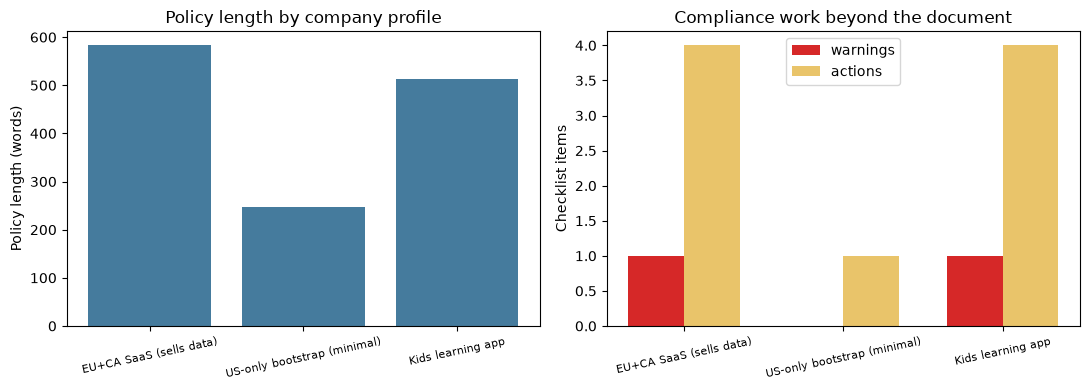

In [5]:
import matplotlib.pyplot as plt
import numpy as np

labels = [r["scenario"] for r in rows]
x = np.arange(len(labels))
w = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(x, [r["words"] for r in rows], color="#457b9d")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=8, rotation=12)
ax1.set_ylabel("Policy length (words)")
ax1.set_title("Policy length by company profile")

ax2.bar(x - w / 2, [r["warnings"] for r in rows], w, label="warnings", color="#d62828")
ax2.bar(x + w / 2, [r["actions"] for r in rows], w, label="actions", color="#e9c46a")
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8, rotation=12)
ax2.set_ylabel("Checklist items")
ax2.set_title("Compliance work beyond the document")
ax2.legend()

fig.tight_layout()
fig.savefig("policy_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Scenario | Sections | Words | Warnings |
|---|---|---|---|
| EU+CA SaaS that sells data | 11 | longest | Do-Not-Sell link required |
| US-only bootstrap | 8 | shortest | none |
| Kids app (EU+CA) | 11 | long | COPPA parental consent |

Same questionnaire, three legally distinct documents — plus a checklist of the work the document can't do (consent banners, DPAs, homepage links, lawyer review). That last item never goes away: **this is a starting draft, not legal advice.**


## Try your own

Uncomment and describe your product:

In [6]:
# mine = CompanyProfile(
#     company="My Startup",
#     website="https://mystartup.example",
#     contact_email="privacy@mystartup.example",
#     data_categories=["contact", "usage"],
#     uses_analytics=True,
#     serves_eu=True,
#     serves_california=False,
#     retention_months=18,
# )
# print(generate_policy(mine, "2026-07-11"))
# for item in compliance_checklist(mine):
#     print(f"[{item['level']}] {item['item']}")

---

Part of **[Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** — 60 mini AI products in 6 months.

Prefer a UI? Run the Streamlit version:

```bash
pip install -r requirements.txt
streamlit run app.py
```
